# Experiment 2: Transfer Learning with ResNet50 (Frozen Base)

## Hypothesis

Using ResNet50 pre-trained on ImageNet as a feature extractor (frozen),
with only a new classifier head trained, should significantly outperform
the baseline CNN. Expected gain: +10-12 percentage points over the 78.6%
baseline.

Rationale: ImageNet-pretrained features capture high-level semantic concepts
(textures, materials, object shapes) that transfer well to waste classification,
where intra-class variance is high.

## Configuration

- Model: ResNet50 + GAP + Dropout + Dense
- Base: frozen (ImageNet weights, not updated)
- Optimizer: Adam, learning rate 1e-3
- Batch size: 32
- Max epochs: 30, EarlyStopping patience=5
- Class weights: not used yet (isolating Transfer Learning effect)

In [12]:
import os
import shutil

if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

!git clone https://github.com/wayofell/trash-classification.git
%cd trash-classification

import sys
sys.path.insert(0, '.')

import tensorflow as tf
print(f"TF version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Cloning into 'trash-classification'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 49 (delta 17), reused 40 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 4.43 MiB | 31.91 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/kaggle/working/trash-classification
TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
from src.data import load_dataset, CLASS_NAMES, NUM_CLASSES
from src.model import build_resnet50_transfer
from src.train import compile_and_train, evaluate_on_test
from src.utils import (
    log_experiment, plot_training_curves,
    collect_predictions, plot_confusion_matrix, print_classification_report,
    get_experiments_dir
)

print("All imports OK")

All imports OK


In [17]:
BATCH_SIZE = 32

train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=BATCH_SIZE)

print("Dataset sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples ({n // BATCH_SIZE} batches)")

Dataset sizes:
  train:  8593 samples (268 batches)
  val  :  1833 samples (57 batches)
  test :  1833 samples (57 batches)


In [18]:
model = build_resnet50_transfer(trainable_base=False)

trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)
non_trainable_params = model.count_params() - trainable_params

print(f"Total parameters:         {model.count_params():>12,}")
print(f"Trainable parameters:     {trainable_params:>12,}")
print(f"Non-trainable parameters: {non_trainable_params:>12,}")
print(f"\nOnly {100 * trainable_params / model.count_params():.2f}% of params are trainable")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters:           23,608,202
Trainable parameters:           20,490
Non-trainable parameters:   23,587,712

Only 0.09% of params are trainable


In [20]:
EPOCHS = 30
LEARNING_RATE = 1e-3

history, training_time = compile_and_train(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    optimizer_name="adam",
    class_weight=None,
    verbose=2,
)

print(f"\nTraining finished in {training_time:.1f} seconds "
      f"({training_time/60:.1f} minutes)")
print(f"Total epochs run: {len(history.history['loss'])}")

Epoch 1/30
269/269 - 38s - 141ms/step - accuracy: 0.8551 - loss: 0.4413 - val_accuracy: 0.8969 - val_loss: 0.3329 - learning_rate: 1.0000e-03
Epoch 2/30
269/269 - 15s - 54ms/step - accuracy: 0.9029 - loss: 0.2910 - val_accuracy: 0.9105 - val_loss: 0.2864 - learning_rate: 1.0000e-03
Epoch 3/30
269/269 - 15s - 54ms/step - accuracy: 0.9190 - loss: 0.2384 - val_accuracy: 0.9133 - val_loss: 0.2808 - learning_rate: 1.0000e-03
Epoch 4/30
269/269 - 14s - 54ms/step - accuracy: 0.9287 - loss: 0.2082 - val_accuracy: 0.9100 - val_loss: 0.2737 - learning_rate: 1.0000e-03
Epoch 5/30
269/269 - 14s - 54ms/step - accuracy: 0.9309 - loss: 0.1959 - val_accuracy: 0.9133 - val_loss: 0.2770 - learning_rate: 1.0000e-03
Epoch 6/30
269/269 - 15s - 54ms/step - accuracy: 0.9400 - loss: 0.1711 - val_accuracy: 0.9225 - val_loss: 0.2652 - learning_rate: 1.0000e-03
Epoch 7/30
269/269 - 14s - 54ms/step - accuracy: 0.9416 - loss: 0.1630 - val_accuracy: 0.9176 - val_loss: 0.2779 - learning_rate: 1.0000e-03
Epoch 8/30
2

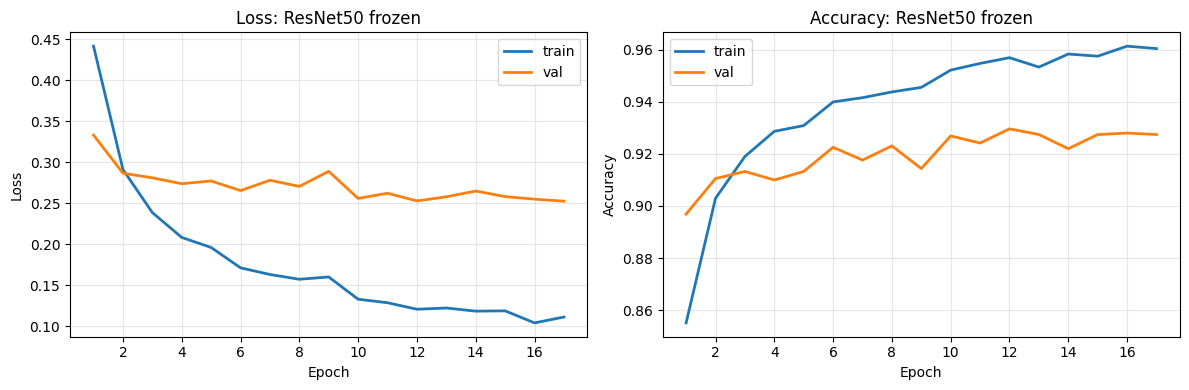

In [21]:
plots_dir = get_experiments_dir() / "plots"

plot_training_curves(
    history,
    title="ResNet50 frozen",
    save_path=plots_dir / "02_resnet50_frozen_curves.png"
)

In [22]:
test_loss, test_acc = evaluate_on_test(model, test_ds)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"\nBest validation accuracy: "
      f"{max(history.history['val_accuracy']):.4f}")
print(f"\nImprovement over baseline (78.61%): "
      f"{(test_acc - 0.7861) * 100:+.2f} pp")

Test loss:     0.2182
Test accuracy: 0.9269 (92.69%)

Best validation accuracy: 0.9296

Improvement over baseline (78.61%): +14.08 pp


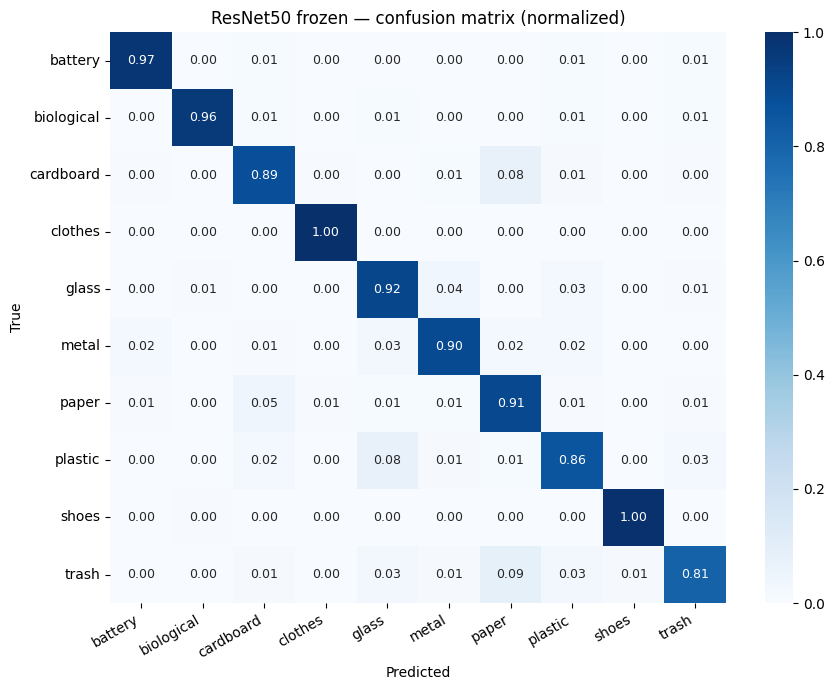

In [23]:
y_true, y_pred = collect_predictions(model, test_ds)

cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names=CLASS_NAMES,
    title="ResNet50 frozen — confusion matrix (normalized)",
    normalize=True,
    save_path=plots_dir / "02_resnet50_frozen_confusion.png"
)

In [24]:
from sklearn.metrics import f1_score

report = print_classification_report(y_true, y_pred, CLASS_NAMES)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Improvement over baseline (0.780): {(macro_f1 - 0.780):+.4f}")

              precision    recall  f1-score   support

     battery      0.957     0.973     0.965       113
  biological      0.971     0.962     0.966       104
   cardboard      0.908     0.886     0.897       211
     clothes      0.993     0.996     0.995       283
       glass      0.898     0.915     0.907       260
       metal      0.874     0.899     0.887       139
       paper      0.871     0.910     0.890       200
     plastic      0.919     0.858     0.887       239
       shoes      0.986     0.995     0.991       217
       trash      0.818     0.806     0.812        67

    accuracy                          0.927      1833
   macro avg      0.919     0.920     0.920      1833
weighted avg      0.927     0.927     0.927      1833


Macro F1: 0.9196
Improvement over baseline (0.780): +0.1396


In [26]:
log_experiment({
    "experiment_name": "02_resnet50_frozen",
    "model": "resnet50_imagenet_frozen",
    "epochs": len(history.history['loss']),
    "batch_size": BATCH_SIZE,
    "optimizer": "adam",
    "learning_rate": LEARNING_RATE,
    "augmentation": "flip+brightness+contrast",
    "class_weights": "none",
    "train_acc": round(history.history['accuracy'][-1], 4),
    "val_acc": round(max(history.history['val_accuracy']), 4),
    "test_acc": round(test_acc, 4),
    "test_macro_f1": round(macro_f1, 4),
    "train_loss": round(history.history['loss'][-1], 4),
    "val_loss": round(min(history.history['val_loss']), 4),
    "test_loss": round(test_loss, 4),
    "training_time_sec": round(training_time, 1),
    "notes": "transfer learning with frozen ImageNet base",
})

import pandas as pd
df = pd.read_csv(get_experiments_dir() / "results.csv")
print(df.to_string(index=False))

          timestamp    experiment_name                    model  epochs  batch_size optimizer  learning_rate             augmentation class_weights  train_acc  val_acc  test_acc  test_macro_f1  train_loss  val_loss  test_loss  training_time_sec                                       notes
2026-05-16T17:27:12    01_baseline_cnn      baseline_cnn_4block      30          32      adam          0.001 flip+brightness+contrast          none     0.7767   0.7889    0.7861         0.7797      0.6716    0.6895     0.6694              322.5        baseline reference, no class weights
2026-05-18T15:20:53 02_resnet50_frozen resnet50_imagenet_frozen      17          32      adam          0.001 flip+brightness+contrast          none     0.9604   0.9296    0.9269         0.9196      0.1111    0.2523     0.2182              269.9 transfer learning with frozen ImageNet base
2026-05-18T15:21:08 02_resnet50_frozen resnet50_imagenet_frozen      17          32      adam          0.001 flip+brightness+contrast

## Findings

### Overall performance
- ResNet50 with frozen ImageNet base reached **92.69%** test accuracy
- Improvement over baseline (78.61%): **+14.08 percentage points**
- Macro F1: **0.920** (baseline: 0.780, improvement: **+0.140**)
- Training converged in 17 epochs (EarlyStopping triggered, best weights from epoch 12)
- Training time: 4.5 minutes — even faster than baseline (5.4 min) despite a
  much larger model, because only 0.09% of parameters are trainable

### Convergence speed
The most striking observation: validation accuracy reached **89.7% on epoch 1**,
which is already higher than the final baseline result (78.6%) after 30 epochs.
This demonstrates that ImageNet pre-trained features transfer directly to
waste classification with minimal adaptation.

### Per-class improvements
Every single class improved over baseline. Largest gains on previously weak classes:

| Class      | Baseline | ResNet50 frozen | Δ      |
|------------|----------|-----------------|--------|
| metal      | 0.66     | 0.90            | +0.24  |
| trash      | 0.58     | 0.81            | +0.23  |
| shoes      | 0.78     | 1.00            | +0.22  |
| glass      | 0.76     | 0.92            | +0.16  |
| battery    | 0.84     | 0.97            | +0.13  |
| cardboard  | 0.76     | 0.89            | +0.13  |
| paper      | 0.79     | 0.91            | +0.12  |
| clothes    | 0.89     | 1.00            | +0.11  |
| plastic    | 0.77     | 0.86            | +0.09  |
| biological | 0.90     | 0.96            | +0.06  |

### Key insight: trash class
The +0.23 improvement on the trash class is particularly interesting.
In EDA we attributed its weakness to high intra-class variance (masks,
gloves, napkins, packaging). The dramatic improvement shows that the
problem was not variance per se but the lack of high-level semantic
features in the baseline. ImageNet features capture object-level concepts
that allow the model to recognize "trash" as a meta-class rather than
trying to learn it from raw pixels.

### Persistent confusion pairs
EDA-predicted confusion pairs are still visible but much weaker:
- paper ↔ cardboard: 9% → 5% (improved)
- glass ↔ metal: 12% → 4% (strongly improved)
- plastic → glass: 11% → 8% (slightly improved, still the most persistent)

The plastic/glass confusion remains the dominant remaining error — likely
due to transparent containers in both classes being visually nearly identical.
This is a candidate for further improvement via fine-tuning.

### Overfitting analysis
Train accuracy reached 96.0% while val plateaued at 92.96%. The 3pp gap
indicates the classifier head is starting to overfit despite frozen base.
This signals that further gains require either:
- Unfreezing some base layers (fine-tuning) — next experiment
- Stronger regularization (more aggressive augmentation, higher dropout)

## Next steps

1. **Fine-tuning (Experiment 3):** unfreeze the last block(s) of ResNet50
   with a low learning rate. Expected gain: +1-3 pp, primarily on the
   persistent plastic/glass confusion.

2. **Class weights (Experiment 5):** the trash class still has the lowest
   F1 (0.812). Class weighting should boost minority class recall.

3. **EfficientNetV2S (Experiment 4):** the paper by the dataset author
   reports 95.13% with EfficientNetV2S. Worth comparing as an
   alternative architecture.